In [1]:
import torch 
import torch.nn as nn 
from torchvision.datasets import FashionMNIST
from torchvision import transforms 
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
def softmax(X):
    X_exp = torch.exp(X)
    X_exp_sum = X_exp.sum(1, keepdim=True)
    return X_exp / X_exp_sum

In [3]:
X = torch.rand((2,5))
X_soft = softmax(X)
X_soft, X_soft.sum(dim=1, keepdim=True)

(tensor([[0.1056, 0.2413, 0.1661, 0.2730, 0.2139],
         [0.1589, 0.3275, 0.1505, 0.2233, 0.1397]]),
 tensor([[1.],
         [1.]]))

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
class SGD():
    def __init__(self, params, lr):
        self.params = params
        self.lr = lr
    def step(self):
        for param in self.params:
            param -= self.lr * param.grad
    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

In [6]:
class SoftmaxRegression(nn.Module):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs), requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)
        self.lr = lr
        
    def loss(self, y_hat, y):
        # There is no observed because it is always 1 , since observed probability is always 1 in multi class classification
        # each element of y_hat is compared with y and its log is taken
        cross_entropy_loss = -torch.log(y_hat[list(range(len(y_hat))), y]).mean()
        return cross_entropy_loss
        
    def configure_optimizer(self,):
        return SGD(self.parameters(), lr=self.lr)
        
    def parameters(self):
        return [self.W, self.b]
        
    def forward(self, X):
        X = X.reshape(-1, self.W.shape[0])
        return torch.matmul(X.to(device), self.W.to(device)) + self.b.to(device)

In [7]:
transform = transforms.Compose([transforms.Resize((28,28)), transforms.ToTensor()])

In [8]:
train_data = FashionMNIST(root ='./data', train=True, transform=transform, download=True)
test_data = FashionMNIST(root ='./data', train=False, transform=transform, download=True)

In [9]:
class Trainer():
    def __init__(self, train_data, test_data, model, max_epochs, batch_size=128, gradient_clip_val = 0):
        self.train_loader = DataLoader(train_data, batch_size, shuffle=True)
        self.test_loader = DataLoader(test_data, batch_size, shuffle=False) 
        self.model = model
        self.max_epochs = max_epochs
        self.gradient_clip_val = gradient_clip_val

    def clip_gradients(self, grad_clip_val, model):
        """Defined in :numref:`sec_rnn-scratch`"""
        params = [p for p in model.parameters() if p.requires_grad]
        norm = torch.sqrt(sum(torch.sum((p.grad ** 2)) for p in params))
        if norm > grad_clip_val:
            for param in params:
                param.grad[:] *= grad_clip_val / norm          
    def fit(self,):
        self.epoch = 0
        self.optim = self.model.configure_optimizer()
        self.train_batch_idx = 0
        self.test_batch_idx = 0
        for self.epoch in range(self.max_epochs):
            self.fit_epoch()      
                
    def fit_epoch(self):
        self.model.train()
        train_loss = []
        train_metric = []
        for images, labels in self.train_loader:
            labels_pred = self.model(images)
            labels_pred_softmax = nn.Softmax(dim=1)(labels_pred)
            # print(y_pred)
            loss = nn.CrossEntropyLoss(reduction='mean')(labels_pred_softmax, labels.to(device)) #model.loss(labels_pred_softmax, labels)    
            self.optim.zero_grad()
            with torch.no_grad():
                loss.backward()
                # print(torch.argmax(y_pred_softmax, dim=1))
                # print(y_pred_softmax.shape)
                # print(y.cpu())
                # print(torch.argmax(y_pred_softmax, dim=1).cpu())
                metric = accuracy_score(labels, torch.argmax(labels_pred_softmax, dim=1).cpu())
                train_loss.append(loss.item())
                train_metric.append(metric)
                # gradient clipping 
                if self.gradient_clip_val > 0:
                    self.clip_gradients(self.gradient_clip_val, self.model)
                self.optim.step()
            self.train_batch_idx += 1
        print(f'At epoch : {self.epoch}') 
        print(f'Train Loss:{np.array(train_loss).mean()}, Train Accuracy: {np.array(train_metric).mean()}')
            
        if self.test_loader is None:
            return 
        self.model.eval()
        test_loss = []
        test_metric = []
        
        for batch in self.test_loader:
            images, labels = batch[0], batch[1]
            labels_pred = self.model(images)
            labels_pred_softmax = nn.Softmax(dim=1)(labels_pred)
            with torch.no_grad():
                loss = nn.CrossEntropyLoss()(labels_pred_softmax, labels.to(device)) #model.loss(labels_pred_softmax, labels) #
                # print(torch.argmax(y_pred_softmax, dim=1))
                # print(y)
                metric = accuracy_score(labels, torch.argmax(labels_pred_softmax, dim=1).cpu())
                test_loss.append(loss.item())
                test_metric.append(metric)
            self.test_batch_idx += 1   
        print(f'Test Loss:{np.array(test_loss).mean()}, Test Accuracy: {np.array(test_metric).mean()}')

    def validate_all(self, data=test_data):
        self.model.eval()
        x_overall, y_overall, y_pred_overall = [], [], []
        for single_example in test_data:
            x = single_example[0]
            y = single_example[1]
            y_pred = self.model(x)
            y_pred_softmax = nn.Softmax(dim=1)(y_pred)
    
            x_overall.append(x)
            y_overall.append(y)
            y_pred_overall.append(torch.argmax(y_pred_softmax, dim=1))
        return x_overall, y_overall, y_pred_overall

In [10]:
model = SoftmaxRegression(num_inputs = 784, num_outputs=10, lr = 0.1).to(device)

In [11]:
trainer = Trainer(train_data, test_data, model, max_epochs=3)

In [12]:
trainer.fit()

At epoch : 0
Train Loss:1.9026138139431918, Train Accuracy: 0.6274264836531627
Test Loss:1.8099204513091076, Test Accuracy: 0.6838409810126582
At epoch : 1
Train Loss:1.7712274693222696, Train Accuracy: 0.7399720149253731
Test Loss:1.7522358833989011, Test Accuracy: 0.7528678797468354
At epoch : 2
Train Loss:1.7349882199565994, Train Accuracy: 0.7674240405117271
Test Loss:1.7312098982967907, Test Accuracy: 0.7662183544303798


In [13]:
x, y, y_pred = trainer.validate_all(test_data)

In [14]:
for a,b,c in zip(x, y, y_pred):
    print(b)
    break

9


In [15]:
wrong_cases = [(x_w, y_w, yp_w) for x_w, y_w, yp_w in zip(x, y, y_pred) if y_w != yp_w]

In [19]:
x_w, y_w, yp_w = wrong_cases[0]

In [23]:
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

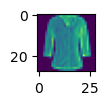

Real : Shirt
Predicted : Pullover


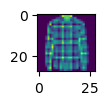

Real : Shirt
Predicted : Coat


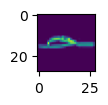

Real : Sandal
Predicted : Sneaker


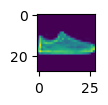

Real : Sneaker
Predicted : Sandal


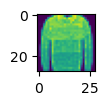

Real : Pullover
Predicted : T-shirt/top


In [43]:
for wrong_case in wrong_cases[:5]:
    plt.figure(figsize=(0.75,0.75))
    plt.imshow(wrong_case[0][0])
    plt.show()
    print(f'Real : {labels[wrong_case[1]]}')
    print(f'Predicted : {labels[wrong_case[2]]}')